In [ ]:
!pip install langgraph langchain-groq langchain-tavily pygraphviz tavily

In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator

In [ ]:
from langchain_core.messages import AnyMessage, SystemMessage, ToolMessage, HumanMessage

In [ ]:
from langchain_tavily import TavilySearch

In [ ]:
import getpass
import os

In [ ]:
if "GROQ_API_KEY" not in os.environ:
  os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq api key Here:")

In [ ]:
if "TAVILY_API_KEY" not in os.environ:
  os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your tavilly api key here : ")

In [ ]:
# tool = TavilySearch(max_results = 2)
# print(type(tool))
# print(tool.name)

In [ ]:
# from tavily import TavilyClient
# import os
# tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()

In [ ]:
tavily = TavilySearch(
    max_results=5
)

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

model = llm.bind_tools([tavily])

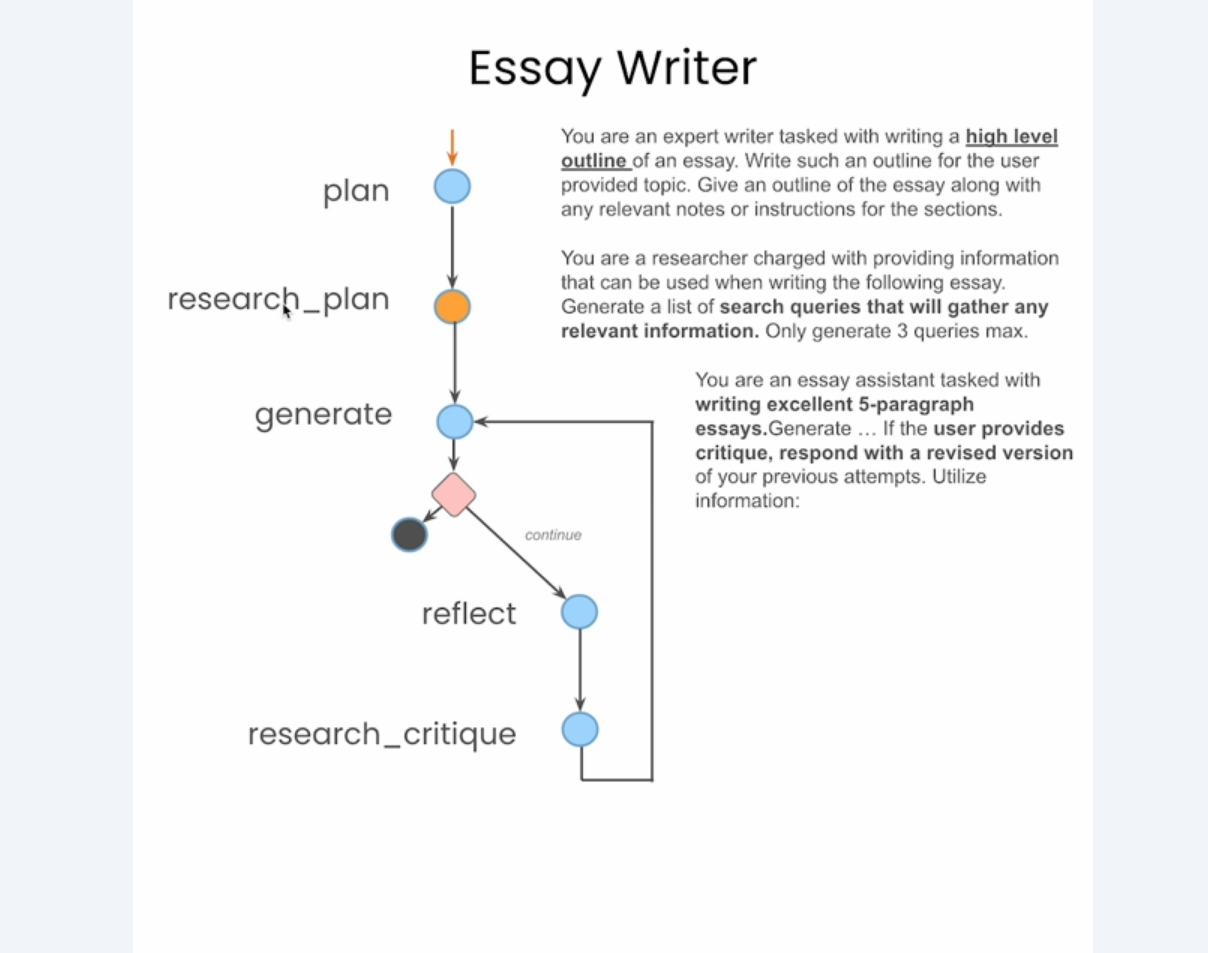

In [ ]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [ ]:
# Plan Node
plan_prompt="You are an Expert Writer tasked with writing a high level outline of an Essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes or instructions for the Section"

In [ ]:
def plan_node(state: AgentState):
  messages = [
      SystemMessage(content=plan_prompt),
      HumanMessage(content=state["task"])
  ]
  response = model.invoke(messages)
  return {"plan": response.content}

In [ ]:
# Research Node
research_plan_prompt="You are a researcher charged with providing inforamtion that can be used when writing the following essay. Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."

In [ ]:
from pydantic import BaseModel

class Queries(BaseModel):
  queries: List[str]

In [ ]:
# def research_plan_node(state: AgentState):
#   messages = [
#       SystemMessage(content=research_plan_prompt),
#       HumanMessage(content=state['task'])
#   ]
#   content = state['content'] or []
#   for q in queries.queries:
#     response = TavilySearch(query=q, max_results=2)
#     for r in response['results']:
#       content.append(r['content'])
#   return {'content':content}
def research_plan_node(state: AgentState):
    queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=research_plan_prompt),
        HumanMessage(content=state['task'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = TavilySearch(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [ ]:
# Generate Node
writer_prompt="""You are an Essay Assistant tasked with writing excellent 5-paragraph essays.Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed:

------

{content} """

In [ ]:
def generation_node(state: AgentState):
  content = "\n\n".join(state['content'] or [])
  user_message = HumanMessage(
      content=f"{state['task']}\n\n Here is my plan:\n\n{state['plan']}"
  )
  messages = [
      SystemMessage(
          content=writer_prompt.format(content=content)
      ),
      user_message
  ]
  response = model.invoke(messages)
  return {
      "draft":response.content,
      "revision_number": state.get("revision_number", 1) + 1
  }

In [ ]:
# Reflect Node
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [ ]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [ ]:
# Research Critique Node

In [ ]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


In [ ]:
def research_critique_node(state: AgentState):
    queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = TavilySearch(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [ ]:
# ACTION
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [ ]:
builder = StateGraph(AgentState)

In [ ]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [ ]:
builder.set_entry_point("planner")

In [ ]:
builder.add_conditional_edges(
    "generate",
    should_continue,
    {END: END, "reflect": "reflect"}
)


In [ ]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [ ]:
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
    'task': "what is the difference between langchain and langsmith",
    "max_revisions": 2,
    "revision_number": 1,
}, thread):
    print(s)